In [112]:
import matplotlib.pyplot as plt
import numpy as np
import copy
import math

In [113]:
data=np.loadtxt("my_data/data1.txt",delimiter=',')
X=data[:,:3]#取列才这么取
y=data[:,3]
X=(X-np.mean(X,axis=0))/(np.std(X,axis=0))
y=(y-np.mean(y,axis=0))/(np.std(y,axis=0))
w_unit=np.zeros(3)
b_unit=0

In [114]:
def predict(x,w,b):
    p=np.dot(x,w)+b
    return p

In [115]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0.0
    for i in range(m):
        cost+=(predict(X[i],w,b)-y[i])**2
    return cost/(2*m)

In [116]:
def compute_gradient(X,w,b,y):
    m,n=X.shape
    f_w=np.zeros((n,))
    f_b=0
    for i in range(m):
        err=predict(X[i],w,b)-y[i]
        f_b+=err
        for j in range(n):
            f_w[j]+=err*X[i,j]
    return f_w/m,f_b/m

In [131]:
def gradient_descent(X,w_in,y,b_in,cost_fuction,gradient_fuction,alpha,num_iters):
    w=copy.deepcopy(w_in)
    b=b_in
    cost=[]
    for i in range(num_iters):
        f_w,f_b=gradient_fuction(X,w,b,y)
        w=w-alpha*f_w
        b=b-alpha*f_b
        if(i<10000):
            cost.append(cost_fuction(X,y,w,b))
        if(i%math.ceil(num_iters/10)==0):
            print(f"cnt{i:4d}:cost{cost[-1]:8.6f}")
    return w,b,cost

In [132]:
print(w_unit.shape)

(3,)


In [133]:
alpha=0.01
num_iters=10000
w,b,J=gradient_descent(X,w_unit,y,b_unit,compute_cost,compute_gradient,alpha,num_iters)
print(w,b)

cnt   0:cost0.487572
cnt1000:cost0.001453
cnt2000:cost0.001452
cnt3000:cost0.001452
cnt4000:cost0.001452
cnt5000:cost0.001452
cnt6000:cost0.001452
cnt7000:cost0.001452
cnt8000:cost0.001452
cnt9000:cost0.001452
[0.91482537 0.14008123 0.14626141] -7.773781618426114e-16


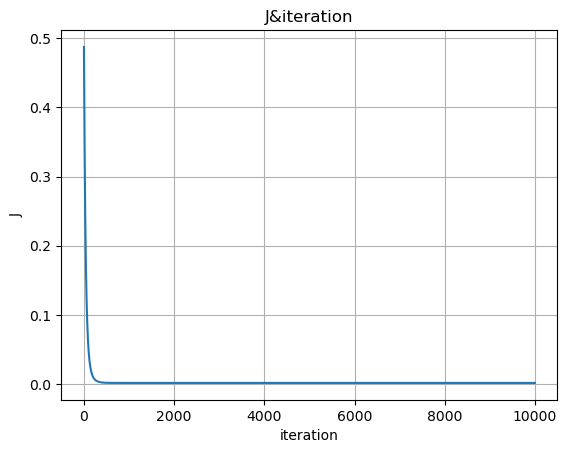

In [138]:
plt.plot(np.arange(len(J)),J)
plt.title("J&iteration")
plt.ylabel("J")
plt.xlabel("iteration")
plt.grid(True)
plt.show()